In [2]:
from mpi4py import MPI
import coqui

import numpy as np
from scipy.constants import physical_constants
HARTREE_EV = physical_constants['Hartree energy in eV'][0]

import matplotlib.pyplot as plt

# Create CoQui MPI handler and set logging verbosity in the beginning
coqui_mpi = coqui.MpiHandler()
coqui.set_verbosity(coqui_mpi, output_level=1)

--------------------------------------------------------------------------
Ignoring value for oob_tcp_if_exclude on ccqlin065 (10.250.112.0/20: Did not find interface matching this subnet).
(You can safely ignore this message.)
--------------------------------------------------------------------------


# Constrained random phase approximation (cRPA)

<figure style="text-align: center;">
 <img src="../../images/svo_crpa_cartoon_ver2.png" alt="cRPA svo" width="40%">
 <figcaption><em>Figure&nbsp;1:</em> Different types of screening processes, involving transitions between the target subspace $\mathcal{C}$ and the environment $\mathcal{B}\backslash\mathcal{C}$.</figcaption>
</figure>

In this notebook, we compute effective Coulomb interactions for a chosen Hilbert subspace using the constrained random phase approximation (cRPA).

In cRPA, the full Hilbert space $\mathcal{B}$ is partitioned into a target subspace $\mathcal{C}$ and the environment $\mathcal{B}\backslash\mathcal{C}$ which contains all remaining degrees of freedom. This partitioning gives rise to three types of screening processes, illustrated in Figure 1: (1) transitions between $\mathcal{C}$ and $\mathcal{B}\backslash\mathcal{C}$, (2) transitions within the environment $\mathcal{B}\backslash\mathcal{C}$, and (3) transitions within the subspace $\mathcal{C}$.

The cRPA screened interaction

$$
\tilde{U}_{\mathrm{cRPA}}(\mathbf{q}, i\Omega_{n}) = V(\mathbf{q}) + V(\mathbf{q})\Pi_{\mathrm{cRPA}}(\mathbf{q}, i\Omega_n)W(\mathbf{q}, i\Omega_{n})
$$

is defined via a *partially* screened polarization $\Pi_{\mathrm{cRPA}}$ in which screening processes internal to $\mathcal{C}$ are excluded:

$$
\Pi_{\mathrm{cRPA}}(\mathbf{q}, i\Omega_n) = \Pi_{\mathrm{RPA}}(\mathbf{q}, i\Omega_n) - \Pi^{(3)}_{\mathrm{RPA}}(\mathbf{q}, i\Omega_n).
$$

Physically, $\tilde{U}_{\mathrm{cRPA}}$ can be viewed as an effective bare Coulomb interaction for the subspace $\mathcal{C}$. 
When constructing low-energy models restricted to $\mathcal{C}$, removing the intra-subspace screening ensures that these processes are not double-counted, since they will be treated explicitly when solving the effective model. 

**What's covered in this notebook**
1. How to compute cRPA screened interactions

2. How to manipulate dynamic correlation functions via the `IAFT` class

3. How to extract Hubbard–Kanamori parameterization from cRPA results

4. How the Wannier window affects static and dynamic effective interactions

First, copy the pre-computed inputs required for this notebook.

This prepares local copies of:

- `svo_222/` (QE and Wannier90 outputs for 2x2x2 SrVO$_3$)

In [3]:
%%bash
python copy_notebook_inputs.py

Copied: data/qe_inputs/svo/222 -> svo_222
Notebook inputs are ready.


### Section 1: cRPA

<figure style="text-align: center;">
 <img src="../../images/coqui_workflow_crpa.png" alt="cRPA workflow in CoQuí" width="60%">
 <figcaption>cRPA workflow in CoQuí.</figcaption>
</figure>

As illustrated in Figure 2, the cRPA workflow in CoQuí closely parallels the $GW$ workflow. Both calculations start from a second-quantized interacting Hamiltonian compressed in the THC representation and take advantages of efficient imaginary-axis Fourier transform using the DLR basis. The target subspace $\mathcal{C}$ is defined using maximally localized Wannier functions (MLWFs).

Starting from an interacting Hamiltonian stored in a `ThcCoulomb` instance, cRPA can be performed through a single call to  `downfold_coulomb`, which carries out the downfolding of the Coulomb interaction into the $\mathcal{C}$ subspace defined by the MLWFs:

>```python
>coqui.downfold_coulomb(h_int: ThcCoulomb, params: dict) -> Tuple[Vloc, Uloc_w]
>```

Function inputs:
- `h_int`: `ThcCoulomb` instance for the Coulomb Hamiltonian

- `params`: dictionary of cRPA parameters. Key parameters include:

    - `outdir` (default: `"."`): output directory

    - `prefix` (required): checkpoint prefix

    - `wannier_file` (required): MLWF HDF5 archive that defines the target subspace $\mathcal{C}$.

    - `screen_type` (required): screening prescription that defines the irreducible polarizability $\Pi(\mathbf{q},i\Omega_{n})$ used to compute the screened interaction $W$. Available options include: `"crpa"`, `"rpa"`, etc.

    - `greens_func_source` (required): determines whether polarization is evaluated using mean-field or interacting electronic structure:
        - `"mf"`: uses the mean-field Green's function $G_0$ from the underlying `Mf` object. 

        - `"scf"`: uses the interacting Green's function $G$ obtained from a self-consistent MBPT calculation read from an existing checkpoint

    - `beta` (default: 1000): inverse temperature (in a.u.$^{-1}$).

    - `iaft` (dict, optional): imaginary-axis frequency-grid settings:
        - `wmax` (float, optional, units: Hartree) — DLR frequency cutoff. If omitted, estimated automatically from the mean-field bandwidth.

        - `prec` (str, optional, default `"medium"`) — target numerical precision: `"high"` (1e-13), `"medium"` (1e-10), `"low"` (1e-6).
        
        - `eps` (float, optional) — explicit accuracy target; alternative to `prec`.
    
    > Note: `beta` and `iaft` are only used when the Green's function is built fresh (e.g. `greens_func_source="mf"` with no matching checkpoint). If the Green's function is read from an existing checkpoint, the imaginary-axis frequency grid and temperature are already fixed by the checkpoint data, and any `beta` or `iaft` values passed here are ignored.

Returned outputs:
- `Vloc`: bare local tensor $V_{abcd}$ in the MLWF basis, with shape $(N_{\mathrm{wann}}, N_{\mathrm{wann}}, N_{\mathrm{wann}}, N_{\mathrm{wann}})$

- `Uloc_w`: dynamic part of the screened interaction $U_{abcd}(i\Omega_n)$ in the MLWF basis, with shape $(N^{+}_{\mathrm{freq}}, N_{\mathrm{wann}}, N_{\mathrm{wann}}, N_{\mathrm{wann}}, N_{\mathrm{wann}})$

Here, $N_{\mathrm{wann}}$ denotes the number of MLWFs in the target subspace. The frequency dimension $N^{+}_{\mathrm{freq}}$ contains only the *positive* bosonic Matsubara frequencies on the DLR mesh. Since the screened interaction satisfies the particle-hole symmetry relation
$$
U(-i\Omega_{n}) = U(i\Omega_{n})
$$
the negative-frequency components are redundant and therefore are not stored explicitly.

> The returned downfolded interactions are also stored in the checkpoint `{outdir}/{prefix}.mbpt.h5` under the group `scf/iter{X}/downfolded_model/` where `X` is the iteration number of the self-consistent MBPT calculation from which the Green's function is read.

#### 🔹 Example: cRPA screened interaction for V $t_{2g}$ on SrVO$_3$

We now apply the `downfold_coulomb` function introduced above to a concrete case: computing the cRPA screened interaction for the V $t_{2g}$ subspace of SrVO$_3$. Following the standard three-phase workflow, we (1) build the `Mf` object from the pre-computed QE data, (2) construct the THC Coulomb Hamiltonian, and (3) downfold it onto the $t_{2g}$ target subspace $\mathcal{C}$ defined by the MLWFs in `svo_222/mlwf/svo.mlwf.h5`.

In [4]:
nbnd = 40
mf_params = {
    "prefix": "svo",
    "outdir": "svo_222/out",
    "nbnd": nbnd
}
mf = coqui.make_mf(coqui_mpi, params=mf_params, mf_type="qe")

thc_params = {
    "ecut": 1.2 * mf.ecutwfc(),
    "thresh": 1e-3
}
thc = coqui.make_thc_coulomb(mf=mf, params=thc_params)

crpa_params = {
    "screen_type": "crpa",
    "greens_func_source": "mf",
    "prefix": f"crpa_{nbnd}", 
    "wannier_file": "svo_222/mlwf/svo.mlwf.h5", 
}
Vloc, Uloc_iw = coqui.downfold_coulomb(h_int=thc, params=crpa_params)

  Quantum ESPRESSO reader
  -----------------------
  Number of spins                = 1
  Number of polarizations        = 1
  Number of bands                = 40
  Monkhorst-Pack mesh            = (2,2,2)
  K-points                       = 8 total, 4 in the IBZ
  Number of electrons            = 41.0
  Electron density energy cutoff = 360.000 a.u. | FFT mesh = (45,45,45)
  Wavefunction energy cutoff     = 51.704 a.u. | FFT mesh = (23,23,23), Number of PWs = 6859


╔═╗╔═╗╔═╗ ╦ ╦╦  ╔╦╗┬ ┬┌─┐╔═╗┌─┐┬ ┬┬  ┌─┐┌┬┐┌┐ 
║  ║ ║║═╬╗║ ║║   ║ ├─┤│  ║  │ ││ ││  │ ││││├┴┐
╚═╝╚═╝╚═╝╚╚═╝╩   ╩ ┴ ┴└─┘╚═╝└─┘└─┘┴─┘└─┘┴ ┴└─┘

  Algorithm                       = ISDF
  THC integrals access            = incore
  Found precomputed THC integrals = false
  --> CoQuí will compute THC integrals.

  ERI::thc Computation Details
  ----------------------------
  Energy cutoff                = 62.04515704826502 a.u. | FFT mesh = (25,25,25), Number of PWs = 8925
  Threshold                    = 0.001

****************

Check the output log and identify the orbital-averaged Coulomb interactions.

- What are the orbital-averaged *bare* and *static screened* interactions?

- Reference cRPA values for the V $t_{2g}$ subspace of SrVO$_3$ [[1]](https://journals.aps.org/prb/abstract/10.1103/PhysRevB.86.165105) are bare $U \sim 16$ eV, static screened $U(0) \sim 3.5$ eV, and $J \sim 0.6$ eV. How do your computed values compare?

You should find that the *bare* interaction agrees well with the literature, while the *static screened* interaction is somewhat sensitive and may deviate. The reason lies in how each quantity is determined:

- The *bare* interaction is fixed solely by the spatial localization of the MLWFs and is independent of the number of unoccupied bands included in the polarization. It depends only mildly on the k-mesh, through the Wannierization procedure. It is therefore robust and easy to reproduce.

- The *static screened* interaction depends sensitively on both the number of bands (`nbnd`) and the k-point mesh used in the polarization. Convergence with respect to these parameters should always be checked carefully — the small mesh used here is not converged.

> Note: Small imaginary components may appear if MLWFs are not strictly real, often due to limited k-mesh size in Wannierization.

### Section 2: Manipulate dynamical correlation functions on the imaginary axis

Post-processing of correlation functions is an essential part of many-body simulations. 

Common tasks include, but not limited to, (i) inspecting the frequency dependence of quantities such as screened interactions or self-energies, (ii) transforming between imaginary-time and Matsubara-frequency representations for analysis, (iii) evaluating functions on meshes different from the native DLR grid, and (iV) analytical continuation to the real axis.

In CoQuí, the output correlation functions are always on imaginary axis sampled on DLR meshes. For flexible analysis and visualization, being able to manipulate these objects on the imaginary axis directly in is therefore very useful.

CoQuí provides the `IAFT` class for this purpose. `IAFT` encapsulates the DLR basis and offers utilities to:
- generate fermionic/bosonic $\tau$ and $i\omega_n$ meshes,

- perform Fourier transforms between $\tau$ and $i\omega_n$,

- interpolate correlation functions to arbitrary points on the imaginary axis.

Constructor:
>```python
>coqui.IAFT.from_coqui_chkpt(chkpt_h5: str) -> IAFT
>```

- `chkpt_h5` (required): CoQuí checkpoint file.

The constructor reads DLR basis metadata from the checkpoint and returns an `IAFT` object.  

> Check `help(coqui.IAFT)` to inspect full functionality. 

#### 🔹 Example: IAFT basics and visualize cRPA frequency dependence 

Using the cRPA screened interaction computed in the previous section, this example demonstrates how to initialize the `IAFT` class from the CoQuí checkpoint and illustrates several common usages of its methods, including mesh generation, interpolation, and transformations on the imaginary axis.

In the last part of this example, we plot the frequency dependence of representative matrix elements of the cRPA screened interaction:

$$
\tilde{U}(i\Omega_{n}) = V_{abcd} + U_{abcd}(i\Omega_n)
$$

where $V_{abcd}$ is the bare interaction and $U_{abcd}(i\Omega_n)$ is the dynamic part of the screening contribution returned from `downfold_coulomb`. 

> Note: CoQui inputs and outputs are given in atomic units; Use the `HARTREE_EV` constant to convert interactions from Hartree to eV. 

Fermionic Matsubara indices: [   1    3    5    7    9   11   13   15   17   19   23   27   37   43
   51   69   95  113  135  177  239  323  393  473  589  747  959 1275
 3017 5877]  Mesh details on the imaginary axis
  ----------------------------------
  Discrete Lehmann Representation
  Beta                   = 1000.0 a.u.
  Frequency cutoff       = 2.938399981857951 a.u.
  Lambda                 = 2938.399981857951
  Precision              = medium (i.e. eps = 1e-10)
  nt_f, nt_b, nw_f, nw_b = 60, 60, 60, 61


Fermionic Matsubara indices in physical notation: [   0    1    2    3    4    5    6    7    8    9   11   13   18   21
   25   34   47   56   67   88  119  161  196  236  294  373  479  637
 1508 2938]


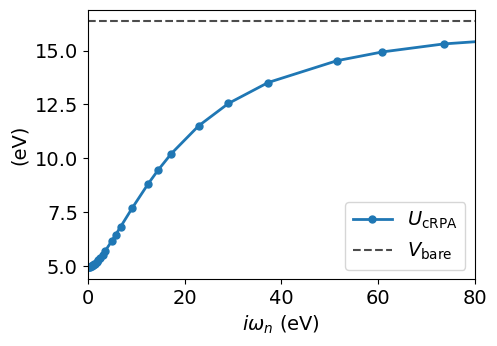

In [5]:
from coqui import IAFT

# --- Initialization ---
iaft = IAFT.from_coqui_chkpt(f"crpa_{nbnd}.mbpt.h5")

# --- Mesh points ---
# tau points go from [0, beta]
tau_mesh_fermion, tau_mesh_boson = iaft.tau_mesh(stats='fermion'), iaft.tau_mesh(stats='boson')
# Matsubara frequency points are odd (fermion) or even (boson) integers 
# **NOTE** the physical Matsubara frequency should be multiplied by 2*pi/beta
wn_mesh = iaft.wn_mesh(stats='fermion', positive_only=True)
print(f"Fermionic Matsubara indices: {wn_mesh}")
wn_mesh_phys = iaft.wn_mesh(stats='fermion', phys_notation=True, positive_only=True)
print(f"Fermionic Matsubara indices in physical notation: {wn_mesh_phys}")

# --- Fourier transform ---
Uloc_t = iaft.w_to_tau(Uloc_iw, stats='boson', ph_sym=True)

# --- Interpolation ---
Uloc_zero_beta = iaft.tau_interpolate(Uloc_t, [0, iaft.beta], stats='boson', ph_sym=True)

# --- Plotting frequency dependence of screened interaction ---
iw_mesh_pos = iaft.wn_mesh(stats='b', positive_only=True) * np.pi / iaft.beta

fig, ax = plt.subplots(1, figsize=(5,3.5), dpi=100)
ax.plot(iw_mesh_pos*HARTREE_EV, (Vloc[0,0,0,0]+Uloc_iw[:,0,0,0,0]).real*HARTREE_EV,
        linewidth=2, marker='o', markersize=5, label=r'$U_{\mathrm{cRPA}}$')
ax.axhline(y=Vloc[0,0,0,0].real*HARTREE_EV, color="black", 
           linestyle="--", linewidth=1.5, alpha=0.7, label=r'$V_{\mathrm{bare}}$')
ax.set_xlim(0, 80)
ax.tick_params(axis='both', which='major', labelsize=14)
ax.set_xlabel(r'$i\omega_{n}$ (eV)', fontsize=14)
ax.set_ylabel('(eV)', fontsize=14)
ax.legend(fontsize=14)
plt.show()

#### 🔹 Example: Analytic continuation to real frequency

As seen in the previous example, correlation functions on the imaginary axis are smooth and numerically well behaved, which makes calculations on the imaginary axis particularly convenient for many-body simulations. Most experimental observables, however, probe dynamical response functions on the real-frequency axis. 

Obtaining real-frequency quantities therefore requires analytic continuation from the imaginary axis to $\omega + i0^{+}$, as discussed in [the previous tutorial](../02_gw/02_gw_electronic_structure.ipynb). 

CoQuí provides several continuation utilities in `coqui.post_proc`. Here we use the native Padé implementation, `coqui.post_proc.pade`, to continue a representative matrix element of the dynamic screened interaction, $U_{0000}(i\Omega_n)$, to the real axis. We then examine the resulting spectral function $-\operatorname{Im}U(\omega)$ together with the real part $\operatorname{Re}U(\omega)$.

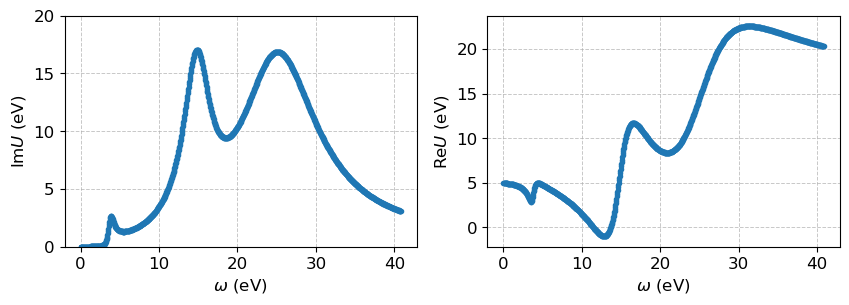

In [7]:
Uw_pade, w_mesh_pade = coqui.post_proc.pade(
    Uloc_iw[:,0,0,0,0], iaft, stats='boson', wmin=0.0, wmax=1.5, Nw=1000, Nfit=100, 
    eta=None, ph_sym=True
)

fig, ax = plt.subplots(1, 2, figsize=(10,3))
ax[0].plot(w_mesh_pade.real * HARTREE_EV, -Uw_pade.imag * HARTREE_EV, 
           linewidth=2, marker='o', markersize=3)
ax[0].set_ylim(0, 20)
ax[0].tick_params(axis='both', which='major', labelsize=12)
ax[0].set_xlabel(r'$\omega$ (eV)', fontsize=12)
ax[0].set_ylabel(r'Im$U$ (eV)', fontsize=12)
ax[0].grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)

ax[1].plot(w_mesh_pade.real * HARTREE_EV, (Vloc[0,0,0,0]+Uw_pade).real * HARTREE_EV, 
           linewidth=2, marker='o', markersize=3)
ax[1].tick_params(axis='both', which='major', labelsize=12)
ax[1].set_xlabel(r'$\omega$ (eV)', fontsize=12)
ax[1].set_ylabel(r'Re$U$ (eV)', fontsize=12)
ax[1].grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)
plt.show()

The real-frequency spectrum provides a direct view of the screening channels retained in the cRPA interaction.

1. **A gap at low frequency.** $-\operatorname{Im}\tilde{U}(\omega)$ stays zero up to a finite onset rather than rising from $\omega = 0$. This gapped, insulating-like screening response is a direct consequence of the cRPA construction: the low-energy particle–hole transitions *within* the V $t_{2g}$ subspace are removed from $\Pi_{\mathrm{cRPA}}$, so there are no metallic (gapless) screening channels left. The remaining screening comes only from higher-energy interband transitions involving the environment.

2. **A plasmon-like peak around $\sim 15$ eV.** The pronounced high-frequency feature corresponds to the collective charge (plasmon) excitations of the environment $\mathcal{B}\backslash\mathcal{C}$. Below this energy scale the environment screens efficiently, so $\operatorname{Re}\tilde{U}(\omega)$ is strongly reduced from the bare value; above it $\operatorname{Re}\tilde{U}(\omega)$ approaches the bare interaction $V$.

#### 🔹 Post-processing / interpretation: extract Hubbard–Kanamori parameters

The local interaction from `downfold_coulomb` is a four-index tensor in the MLWF basis. For many applications, this tensor is reduced to a small set of **Hubbard–Kanamori** parameters — the intra-orbital repulsion $U$, the inter-orbital repulsion $U'$, and the Hund's coupling $J$ — which parameterize the Kanamori Hamiltonian for a set of degenerate, cubic-symmetric orbitals (such as the V $t_{2g}$ shell):

$$
\hat{H}_{\mathrm{HK}} = U\sum_{i}\hat{n}_{i\uparrow}\hat{n}_{i\downarrow}
+ U'\sum_{i\neq j}\hat{n}_{i\uparrow}\hat{n}_{j\downarrow}
+ (U'-J)\sum_{i<j,\,\sigma}\hat{n}_{i\sigma}\hat{n}_{j\sigma}
- J\sum_{i\neq j}\hat{c}^{\dagger}_{i\uparrow}\hat{c}_{i\downarrow}\hat{c}^{\dagger}_{j\downarrow}\hat{c}_{j\uparrow}
+ J\sum_{i\neq j}\hat{c}^{\dagger}_{i\uparrow}\hat{c}^{\dagger}_{i\downarrow}\hat{c}_{j\downarrow}\hat{c}_{j\uparrow},
$$

where $i,j$ label orbitals and $\sigma$ the spin. The first three terms are density–density interactions (intra-orbital, inter-orbital opposite-spin, and inter-orbital same-spin), while the last two are the spin-flip and pair-hopping terms. These parameters are read off from the static screened tensor $\tilde{U}_{abcd}(0)$ as

$$
U = \langle \tilde{U}_{iiii}(0)\rangle_i,\quad
U' = \langle \tilde{U}_{iijj}(0)\rangle_{i\neq j},\quad
J_{\text{spin-flip}} = \langle \tilde{U}_{ijji}(0)\rangle_{i\neq j},\quad
J_{\text{pair-hopping}} = \langle \tilde{U}_{ijij}(0)\rangle_{i\neq j}.
$$

For orbitals related by cubic symmetry, the Kanamori parameters obey the **rotational-invariance relations**
$$
U' \approx U - 2J,\qquad
J_{\text{spin-flip}} = J_{\text{pair-hopping}} \equiv J,
$$
which serve as a useful consistency check on the downfolded interactions.

In the following example, we will
1. Build the static screened interaction $\tilde{U}_{abcd}(0) = V_{abcd} + U_{abcd}(\Omega_n = 0)$.
2. Extract $U$, $U'$, $J_{\text{spin-flip}}$, and $J_{\text{pair-hopping}}$ using the orbital averages above.
3. Check the rotational-invariance relations $U' \approx U - 2J$ and $J_{\text{spin-flip}} = J_{\text{pair-hopping}}$ for the cRPA results.
4. Compare with the CoQuí log summaries and literature values.

In [12]:
# Your task: Write a function to return orbital-average parametrization of the Hubbard Kanamori model
def orb_avg_coulomb(V_abcd):
    norb = V_abcd.shape[0]

    U = 0
    for i in range(norb):
        U += V_abcd[i,i,i,i]
    U /= norb

    Up = 0
    for i in range(norb):
        for j in range(i+1,norb):
            if i!=j:
                Up += V_abcd[i,i,j,j]
    Up /= (norb * (norb-1) ) / 2

    J_pair = 0
    for i in range(norb):
        for j in range(i+1,norb):
            if i!=j:
                J_pair += V_abcd[i,j,i,j]
    J_pair /= (norb * (norb-1) ) / 2

    J_spin = 0
    for i in range(norb):
        for j in range(i+1,norb):
            if i!=j:
                J_spin += V_abcd[i,j,j,i]
    J_spin /= (norb * (norb-1) ) / 2

    return U, Up, J_pair, J_spin

In [13]:
V, Vp, J_pair, J_spin = orb_avg_coulomb(Vloc.real * HARTREE_EV)
U, Up, J_pair_scr, J_spin_scr = orb_avg_coulomb(Uloc_iw[0].real * HARTREE_EV)
print("Small window")
print("-"*13)
print("Bare Interactions")
print(f"  - Intra-orbital: {V}")
print(f"  - Inter-orbital: {Vp}")
print(f"  - Pair hopping: {J_pair}")
print(f"  - Spin flip:    {J_spin}")
print("Screened Interactions")
print(f"  - Intra-orbital: {V+U}")
print(f"  - Inter-orbital: {Vp+Up}")
print(f"  - Pair hopping: {J_pair+J_pair_scr}")
print(f"  - Spin flip:    {J_spin+J_spin_scr}\n")

Small window
-------------
Bare Interactions
  - Intra-orbital: 16.37589653470425
  - Inter-orbital: 15.013959752834792
  - Pair hopping: 0.6476608254905117
  - Spin flip:    0.6476608254905117
Screened Interactions
  - Intra-orbital: 4.9530959702088975
  - Inter-orbital: 3.8309010027099966
  - Pair hopping: 0.5359908253993707
  - Spin flip:    0.5359908253993707



### Section 3: Effective Coulomb interactions from different models

<figure style="text-align: center;">
 <img src="../../images/svo_crpa_cartoon.png" alt="cRPA svo" width="30%">
 <figcaption><em>Figure&nbsp;3:</em> Energy window of the $dp$ model for SrVO$_{3}$.</figcaption>
</figure>

For a given material, the MLWFs associated with a chosen atomic-orbital character are not unique. They depend on which Kohn-Sham states are used to construct the Wannier subspace, or equivalently on the choice of low-energy model. For example, in SrVO$_3$, a $t_{2g}$-only model spanning only the red bands in Figure 3 gives V $t_{2g}$-like MLWFs that differ from those obtained in a larger $dp$ model spanning both the red and blue bands, where O $2p$ states are included explicitly.

>In the $t_{2g}$-only model, part of the O $p$ character must be folded into the V $t_{2g}$-like Wannier functions to reproduce the low-energy bands. In the larger (dp) model, this hybridization is represented more explicitly by separate O $p$-like Wannier functions, making the V $t_{2g}$-like Wannier functions more localized. 

Changing from a $t_{2g}$-only model to a larger $dp$ model affects the cRPA interaction in two ways:
- The spatial profile of the MLWFs changes, which affects the bare Coulomb matrix elements $V_{abcd}$.

- The set of polarization processes excluded from the screening changes, since a larger target subspace removes more transitions from $\Pi_{\mathrm{cRPA}}$.

#### 🔹 Example: cRPA interactions for the $dp$ model

In this example, we revisit SrVO$_3$, but now construct a $dp$ model that covers both the red and blue bands shown in Figure 3. The resulting model consists of V $3d$ and O $2p$ states, and the corresponding MLWF projectors are provided in `svo_222/mlwf_dp/svo_dp.mlwf.h5`. 

1. Perform a cRPA calculation for the $dp$ model using the MLWF archive `svo_222/mlwf_dp/svo_dp.mlwf.h5`. 

2. Plot $\tilde{U}_{\mathrm{cRPA}}(i\Omega_n)$ for the V $t_{2g}$ orbitals along the imaginary axis and compare it against the $t_{2g}$-only model.

    > Note: The MLWFs in `svo_dp.mlwf.h5` are ordered according to the projector list in [`svo.win`](svo_222/mlwf_dp/svo.win): the first three (indices `0–2`) are the V $t_{2g}$ orbitals (`dxz, dyz, dxy`), followed by the two V $e_g$ orbitals (indices `3–4`) and the nine O $p$ orbitals (indices `5–13`). The V $t_{2g}$ sub-block is therefore the leading $3\times3\times3\times3$ corner of the interaction tensors.

3. Extract the Hubbard–Kanamori parameters of the V $t_{2g}$ sub-block (the first three MLWFs) using the `orb_avg_coulomb` helper from Section 2, and compare them with the $t_{2g}$-only model.

The goal of the comparison is to check that the two effects identified above each leave a recognizable fingerprint on the V $t_{2g}$ interactions:

- **More localized Wannier functions → larger bare $V$.** Including the O $2p$ states sharpens the V $t_{2g}$ orbitals, so the bare $V$ should be larger in the $dp$ model.

- **Fewer screening channels → larger screened $\tilde{U}(0)$.** Moving the O $2p$ states into $\mathcal{C}$ removes the V $3d$–O $2p$ transitions from $\Pi_{\mathrm{cRPA}}$, so the $t_{2g}$ electrons are screened less and the static $\tilde{U}(0)$ should also be larger.

In [9]:
nbnd = 40
# --- Phase 1: Problem setup ---
mf_params = {
    "prefix": "svo",
    "outdir": "svo_222/out",
    "nbnd": nbnd
}
mf = coqui.make_mf(coqui_mpi, params=mf_params, mf_type="qe")

thc_params = {
    "ecut": 1.2 * mf.ecutwfc(),
    "thresh": 1e-3
}
thc = coqui.make_thc_coulomb(mf=mf, params=thc_params)

# --- Phase 2: Simulation (cRPA) ---
crpa_params = {
    "screen_type": "crpa",
    "greens_func_source": "mf",
    "prefix": f"crpa_dp_{nbnd}",
    "wannier_file": "svo_222/mlwf_dp/svo_dp.mlwf.h5",
    "iaft": {"prec": "high"}
}
Vloc_dp, Uloc_iw_dp = coqui.downfold_coulomb(h_int=thc, params=crpa_params)

  Quantum ESPRESSO reader
  -----------------------
  Number of spins                = 1
  Number of polarizations        = 1
  Number of bands                = 40
  Monkhorst-Pack mesh            = (2,2,2)
  K-points                       = 8 total, 4 in the IBZ
  Number of electrons            = 41.0
  Electron density energy cutoff = 360.000 a.u. | FFT mesh = (45,45,45)
  Wavefunction energy cutoff     = 51.704 a.u. | FFT mesh = (23,23,23), Number of PWs = 6859


╔═╗╔═╗╔═╗ ╦ ╦╦  ╔╦╗┬ ┬┌─┐╔═╗┌─┐┬ ┬┬  ┌─┐┌┬┐┌┐ 
║  ║ ║║═╬╗║ ║║   ║ ├─┤│  ║  │ ││ ││  │ ││││├┴┐
╚═╝╚═╝╚═╝╚╚═╝╩   ╩ ┴ ┴└─┘╚═╝└─┘└─┘┴─┘└─┘┴ ┴└─┘

  Algorithm                       = ISDF
  THC integrals access            = incore
  Found precomputed THC integrals = false
  --> CoQuí will compute THC integrals.

  ERI::thc Computation Details
  ----------------------------
  Energy cutoff                = 62.04515704826502 a.u. | FFT mesh = (25,25,25), Number of PWs = 8925
  Threshold                    = 0.001

****************

  Mesh details on the imaginary axis
  ----------------------------------
  Discrete Lehmann Representation
  Beta                   = 1000.0 a.u.
  Frequency cutoff       = 2.938399981857951 a.u.
  Lambda                 = 2938.399981857951
  Precision              = high (i.e. eps = 1e-13)
  nt_f, nt_b, nw_f, nw_b = 74, 74, 74, 75



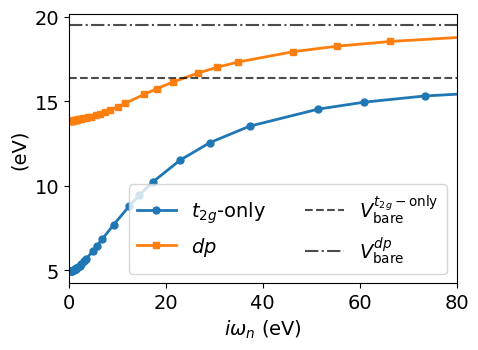

In [10]:
iaft_dp = coqui.IAFT.from_coqui_chkpt(f"crpa_dp_{nbnd}.mbpt.h5")
iw_mesh_pos_dp = iaft_dp.wn_mesh(stats='b', positive_only=True) * np.pi / iaft_dp.beta

fig, ax = plt.subplots(1, figsize=(5,3.5), dpi=100)
ax.plot(iw_mesh_pos*HARTREE_EV, (Vloc[0,0,0,0]+Uloc_iw[:,0,0,0,0]).real*HARTREE_EV,
        linewidth=2, marker='o', markersize=5, label=r'$t_{2g}$-only')
ax.plot(iw_mesh_pos_dp*HARTREE_EV, (Vloc_dp[0,0,0,0]+Uloc_iw_dp[:,0,0,0,0]).real*HARTREE_EV,
        linewidth=2, marker='s', markersize=5, label='$dp$')

ax.axhline(y=Vloc[0,0,0,0].real*HARTREE_EV, color="black", 
           linestyle="--", linewidth=1.5, alpha=0.7, label=r'$V^{t_{2g}-\mathrm{only}}_{\mathrm{bare}}$')
ax.axhline(y=Vloc_dp[0,0,0,0].real*HARTREE_EV, color="black", 
           linestyle="-.", linewidth=1.5, alpha=0.7, label=r'$V^{dp}_{\mathrm{bare}}$')
ax.set_xlim(0, 80)
ax.tick_params(axis='both', which='major', labelsize=14)
ax.set_xlabel(r'$i\omega_{n}$ (eV)', fontsize=14)
ax.set_ylabel('(eV)', fontsize=14)
ax.legend(ncol=2, fontsize=14)
plt.show()

In [14]:
# In svo_dp.mlwf.h5 the MLWFs follow the projector order in svo_222/mlwf_dp/svo.win:
#   indices 0-2 : V t2g (dxz, dyz, dxy),  3-4 : V eg,  5-13 : O p.
# The V t2g orbitals are therefore the leading 3x3x3x3 block of the interaction tensors.
t2g = slice(0, 3)
Vloc_dp_t2g    = Vloc_dp[t2g, t2g, t2g, t2g]
Uloc_iw_dp_t2g = Uloc_iw_dp[:, t2g, t2g, t2g, t2g]

# Kanamori parameters of the V t2g sub-block in the dp model
V, Vp, J_pair, J_spin = orb_avg_coulomb(Vloc_dp_t2g.real * HARTREE_EV)
U, Up, J_pair_scr, J_spin_scr = orb_avg_coulomb(Uloc_iw_dp_t2g[0].real * HARTREE_EV)
print("dp model (V t2g sub-block)")
print("-"*26)
print("Bare Interactions")
print(f"  - Intra-orbital: {V}")
print(f"  - Inter-orbital: {Vp}")
print(f"  - Pair hopping: {J_pair}")
print(f"  - Spin flip:    {J_spin}")
print("Screened Interactions")
print(f"  - Intra-orbital: {V+U}")
print(f"  - Inter-orbital: {Vp+Up}")
print(f"  - Pair hopping: {J_pair+J_pair_scr}")
print(f"  - Spin flip:    {J_spin+J_spin_scr}\n")

dp model (V t2g sub-block)
--------------------------
Bare Interactions
  - Intra-orbital: 19.47432504872035
  - Inter-orbital: 17.784205527048723
  - Pair hopping: 0.8512093092110442
  - Spin flip:    0.8512093092110442
Screened Interactions
  - Intra-orbital: 13.817258912277367
  - Inter-orbital: 12.250923413594784
  - Pair hopping: 0.7896446675741963
  - Spin flip:    0.7896446675741964

